### Deep dive into the learning structure of SAC. Hardware vs. simulation.


Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
train_ant_hw_2025-09-16_14-58-34
train_ant_hw_2025-09-16_15-23-16


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


train_ant_mujoco_2025-09-15_23-31-02


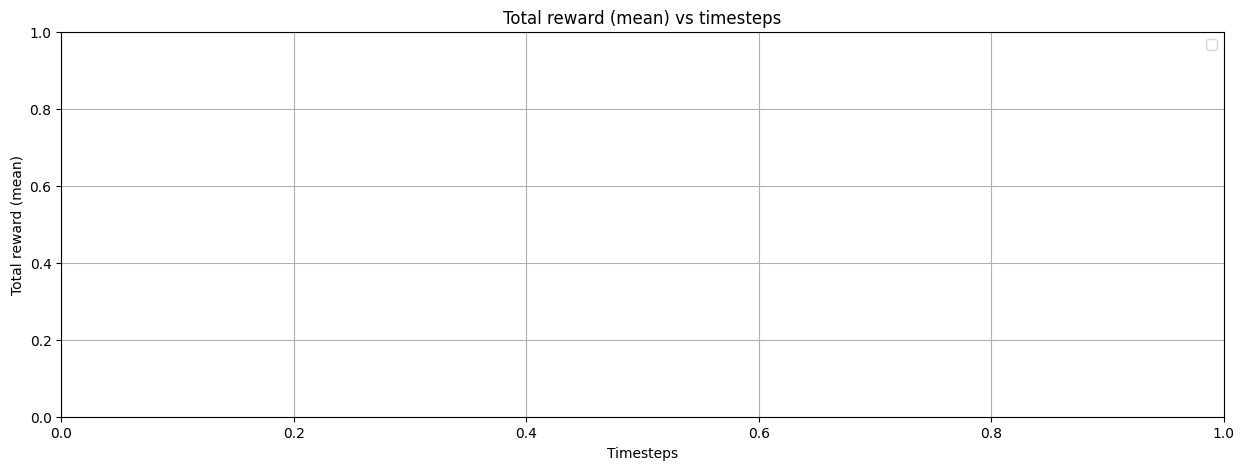

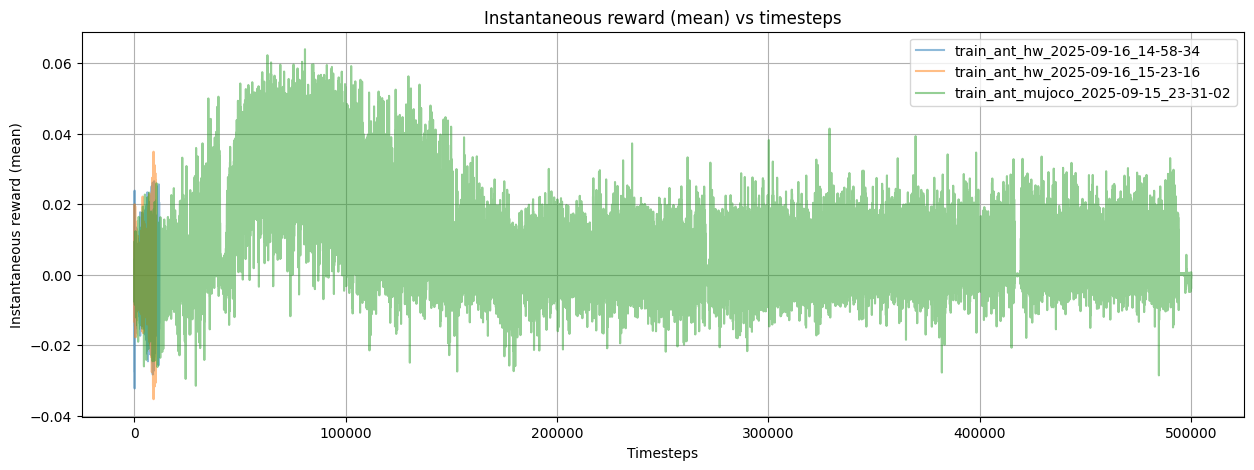

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skrl.utils import postprocessing

labels = []
rewards = []
entropies = []
entropies_losses = []
average_rewards = []
policy_losses = []
critic_losses = []
q1_values = []
q2_values = []
instant_rewards_min = []
instant_rewards_max = []
instant_rewards_mean = []
target_values_mean = []
target_values_max = []
target_values_min = []

prefix_hardware = 'train_ant_hw_'
prefix_sim = 'train_ant_mujoco_'

tensorboard_iterator = postprocessing.TensorboardFileIterator(f"sac_skrl/logs_sac_skrl/*/events.out.tfevents.*",
                                                              tags=[
                                                                #   "Reward / Total reward (mean)",
                                                                    "Coefficient / Entropy coefficient",
                                                                    "Loss / Entropy loss",
                                                                    "Loss / Policy loss",
                                                                    "Loss / Critic loss",
                                                                    "Q-network / Q1 (mean)",
                                                                    "Q-network / Q2 (mean)",
                                                                    "Target / Target (mean)",
                                                                    "Target / Target (max)",
                                                                    "Target / Target (min)",
                                                                    "Reward / Instantaneous reward (mean)",
                                                                    "Reward / Instantaneous reward (max)",
                                                                    "Reward / Instantaneous reward (min)",
                                                                    "average_reward_per_second"])




for dirname, data in tensorboard_iterator:
    print(dirname)  
    # rewards.append(data["Reward / Total reward (mean)"])
    entropies.append(data["Coefficient / Entropy coefficient"])
    entropies_losses.append(data["Loss / Entropy loss"])
    policy_losses.append(data["Loss / Policy loss"])
    critic_losses.append(data["Loss / Critic loss"])
    average_rewards.append(data["average_reward_per_second"])
    q1_values.append(data["Q-network / Q1 (mean)"])
    q2_values.append(data["Q-network / Q2 (mean)"])
    instant_rewards_min.append(data["Reward / Instantaneous reward (min)"])
    instant_rewards_max.append(data["Reward / Instantaneous reward (max)"])
    instant_rewards_mean.append(data["Reward / Instantaneous reward (mean)"])
    target_values_mean.append(data["Target / Target (mean)"])
    target_values_max.append(data["Target / Target (max)"])
    target_values_min.append(data["Target / Target (min)"])
    labels.append(dirname)


fig, ax = plt.subplots(1, 1, figsize=(15, 5))
for reward, label in zip(rewards, labels):
    reward_np = np.array(reward)
    ax.plot(reward_np[:,0], reward_np[:,1], label=label)
ax.set_title("Total reward (mean) vs timesteps")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Total reward (mean)")
ax.grid(True)
ax.legend()

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
for instant_reward_mean, instant_reward_max, instant_reward_min, label in zip(instant_rewards_mean, instant_rewards_max, instant_rewards_min, labels):    
    instant_reward_mean_np = np.array(instant_reward_mean)
    instant_reward_max_np = np.array(instant_reward_max)
    instant_reward_min_np = np.array(instant_reward_min)
    ax.plot(instant_reward_mean_np[:,0], instant_reward_mean_np[:,1], label=label, alpha=0.5)
    # ax.plot(instant_reward_max_np[:,0], instant_reward_max_np[:,1], label=label)
    # ax.plot(instant_reward_min_np[:,0], instant_reward_min_np[:,1], label=label)
    ax.legend()
ax.set_title("Instantaneous reward (mean) vs timesteps")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Instantaneous reward (mean)")
ax.grid(True)
ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


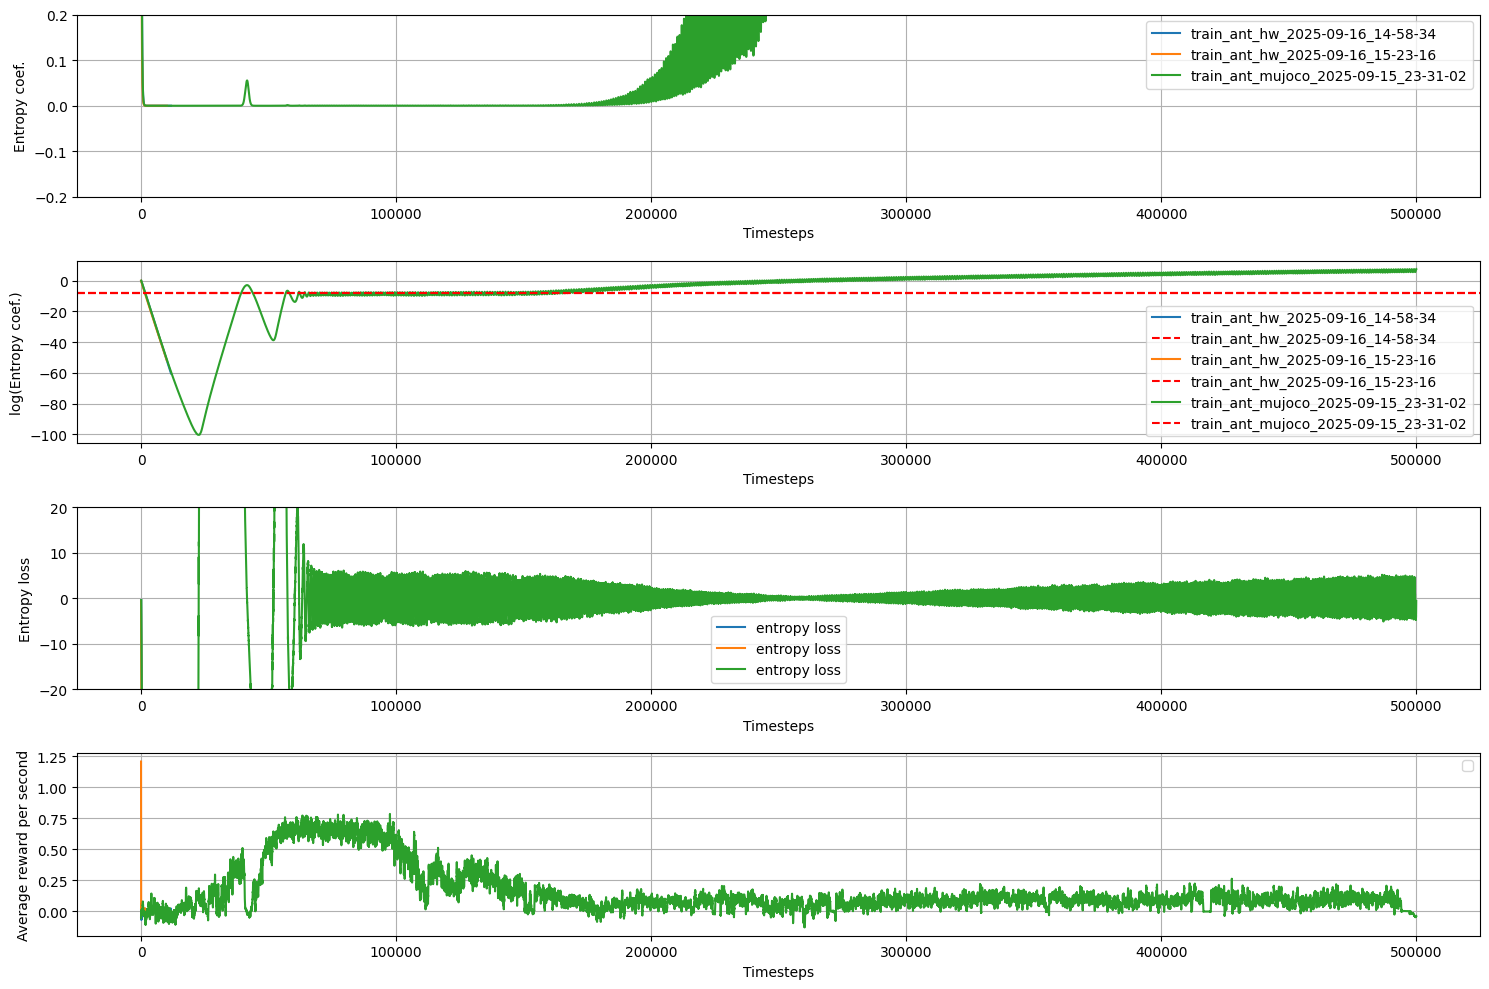

In [2]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10))
for entropy, label in zip(entropies, labels):
    entropy_np = np.array(entropy)
    ax[0].plot(entropy_np[:,0], entropy_np[:,1], label=label)
ax[0].set_xlabel("Timesteps")
ax[0].set_ylabel("Entropy coef.")
ax[0].grid(True)
ax[0].legend()
ax[0].set_ylim(-0.2, 0.2)

for entropy, label in zip(entropies, labels):
    entropy_np = np.array(entropy)
    ax[1].plot(entropy_np[:,0], np.log(entropy_np[:,1]), label=label)   
    ax[1].axhline(y=-8, color='r', linestyle='--', label=label)
ax[1].set_xlabel("Timesteps")
ax[1].set_ylabel("log(Entropy coef.)")
ax[1].grid(True)
ax[1].legend()

for entropy_loss, label in zip(entropies_losses, labels):
    entropy_loss_np = np.array(entropy_loss)
    ax[2].plot(entropy_loss_np[:,0], entropy_loss_np[:,1], label='entropy loss')
ax[2].set_xlabel("Timesteps")
ax[2].set_ylabel("Entropy loss")
ax[2].grid(True)
ax[2].set_ylim(-20, 20)
ax[2].legend()

for average_reward, label in zip(average_rewards, labels):
    average_reward_np = np.array(average_reward)
    ax[3].plot(average_reward_np[:,0], average_reward_np[:,1])
ax[3].set_xlabel("Timesteps")
ax[3].set_ylabel("Average reward per second")
ax[3].grid(True)
ax[3].legend()
plt.tight_layout()


## Entropy learning 

We reparametrize the entropy coefficient as:
$$
\alpha = \exp(\log(\alpha))
$$
and optimize the $\log(\alpha)$ using Adam and $\alpha_{lr}$ as learning rate, with the loss function:
$$
\mathcal{L}_{\log \alpha}=-\mathbb{E}_{s_t \sim \mathcal{D}, a_t \sim \pi\left(\cdot \mid s_t\right)}\left[{\color{red}{\log \alpha}} \cdot\left(\log \pi\left(a_t \mid s_t\right)+\bar{H}\right)\right]
$$

where:
- $s_t \sim \mathcal{D}$ is sampled from the replay buffer.
- $a_t \sim \pi\left(\cdot \mid s_t\right)$ is sampled from the current policy.
- $\bar{H}$ is the target entropy, which is -8 in our case. 

In red we show the term through which gradients are backpropagated.


### Policy learning

We modelled the policy as a Gaussian distribution with a mean and a standard deviation.

$$
\pi(a|s) = \mathcal{N}(\mu(s), diag(\sigma(s)^2))
$$

where:
- $\mu(s)$ is the mean of the Gaussian distribution.
- $\sigma(s)$ is the standard deviation of the Gaussian distribution, learned, independent of the state

A similar log/exp trick is used to learn the standard deviation.

The action $a$ is sampled from the Gaussian distribution using the reparameterization trick:
$$
\mu_\theta(s)+\sigma_\theta \cdot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)
$$

Log prob for a gaussian distribution is:
$$
\log \pi_\theta(a \mid s)=-\frac{1}{2} \sum_{j=1}^k\left[\frac{\left(a_j-\mu_j\right)^2}{\sigma_j^2}+2 \log \sigma_j+\log (2 \pi)\right]
$$

Policy loss is then 
$$
\mathcal{L}_{\text {policy }}=\mathbb{E}_{s \sim \mathcal{D}}\left[\alpha \log \pi_\theta(a \mid s)-\min \left(Q_{\theta_1}(s, a), Q_{\theta_2}(s, a)\right)\right], \quad a \sim \pi_\theta(\cdot \mid s)
$$


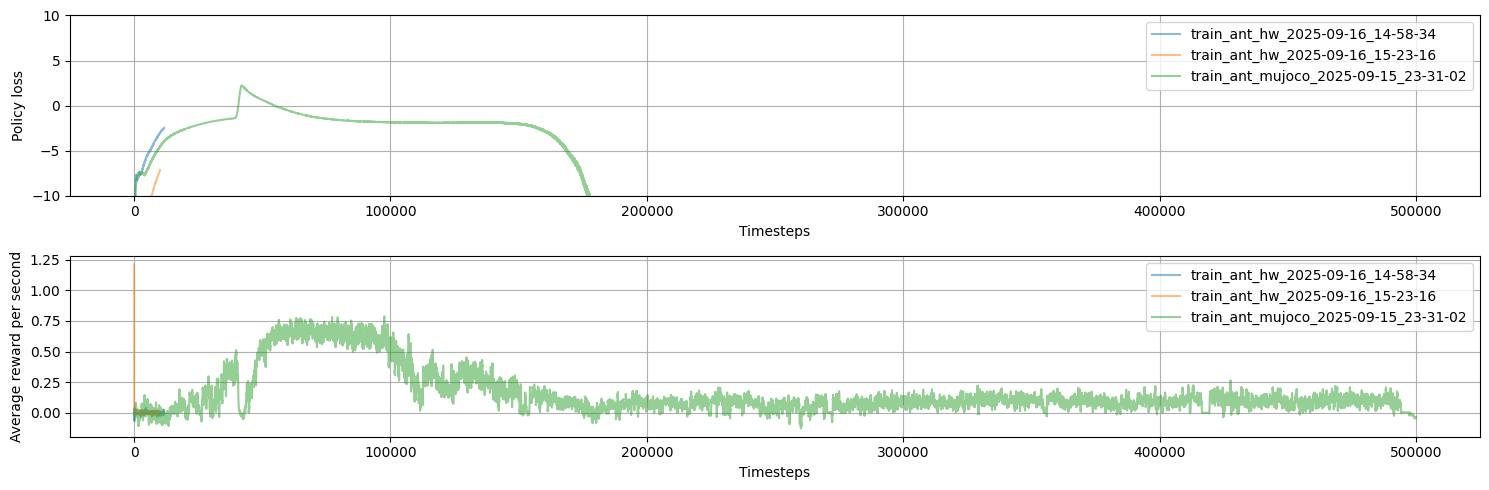

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5))
for policy_loss, label in zip(policy_losses, labels):
    policy_loss_np = np.array(policy_loss)
    ax[0].plot(policy_loss_np[:,0], policy_loss_np[:,1], label=label, alpha=0.5)
ax[0].set_xlabel("Timesteps")
ax[0].set_ylabel("Policy loss")
ax[0].grid(True)
ax[0].legend()
ax[0].set_ylim(-10, 10)

for average_reward, label in zip(average_rewards, labels):
    average_reward_np = np.array(average_reward)
    ax[1].plot(average_reward_np[:,0], average_reward_np[:,1], alpha=0.5, label=label)
ax[1].set_xlabel("Timesteps")
ax[1].set_ylabel("Average reward per second")
ax[1].grid(True)
ax[1].legend()
plt.tight_layout()

Let's look at the target values for the critic.

From the paper, (8), 
$$
\hat{Q}\left(\mathbf{s}_t, \mathbf{a}_t\right)=r\left(\mathbf{s}_t, \mathbf{a}_t\right)+\gamma \mathbb{E}_{\mathbf{s}_{t+1} \sim p}\left[V_{\bar{\psi}}\left(\mathbf{s}_{t+1}\right)\right]
$$

and (3):

$$
V\left(\mathbf{s}_t\right)=\mathbb{E}_{\mathbf{a}_t \sim \pi}\left[Q\left(\mathbf{s}_t, \mathbf{a}_t\right)- \alpha\log \pi\left(\mathbf{a}_t \mid \mathbf{s}_t\right)\right]
$$

Note that there are two Q networks, so the target is computed by taking the minimum of the two Q networks (see line 382 in sac.py of SKRL).


$$
V\left(\mathbf{s}_t\right)=\mathbb{E}_{\mathbf{a}_t \sim \pi}\left[\min(Q_{
    \theta_1}\left(\mathbf{s}_t, \mathbf{a}_t\right), Q_{\theta_2}\left(\mathbf{s}_t, \mathbf{a}_t\right)) - \alpha\log \pi\left(\mathbf{a}_t \mid \mathbf{s}_t\right)\right]
$$


The loss is computed as
$$
J_Q(\theta)=\mathbb{E}_{\left(\mathbf{s}_t, \mathbf{a}_t\right) \sim \mathcal{D}}\left[\frac{1}{2}\left(Q_{\theta_1}\left(\mathbf{s}_t, \mathbf{a}_t\right)-\hat{Q}\left(\mathbf{s}_t, \mathbf{a}_t\right)\right)^2\right] + \mathbb{E}_{\left(\mathbf{s}_t, \mathbf{a}_t\right) \sim \mathcal{D}}\left[\frac{1}{2}\left(Q_{\theta_2}\left(\mathbf{s}_t, \mathbf{a}_t\right)-\hat{Q}\left(\mathbf{s}_t, \mathbf{a}_t\right)\right)^2\right]
$$



Note from the paper: "For the rest of this paper, we will omit writing the temperature explicitly, as it can always be subsumed into the reward by scaling it by α", so that's why it is missing above, but appears in the implementation (see lines 381-382 in sac.py of SKRL).
Also, SAC learns two Q networks.

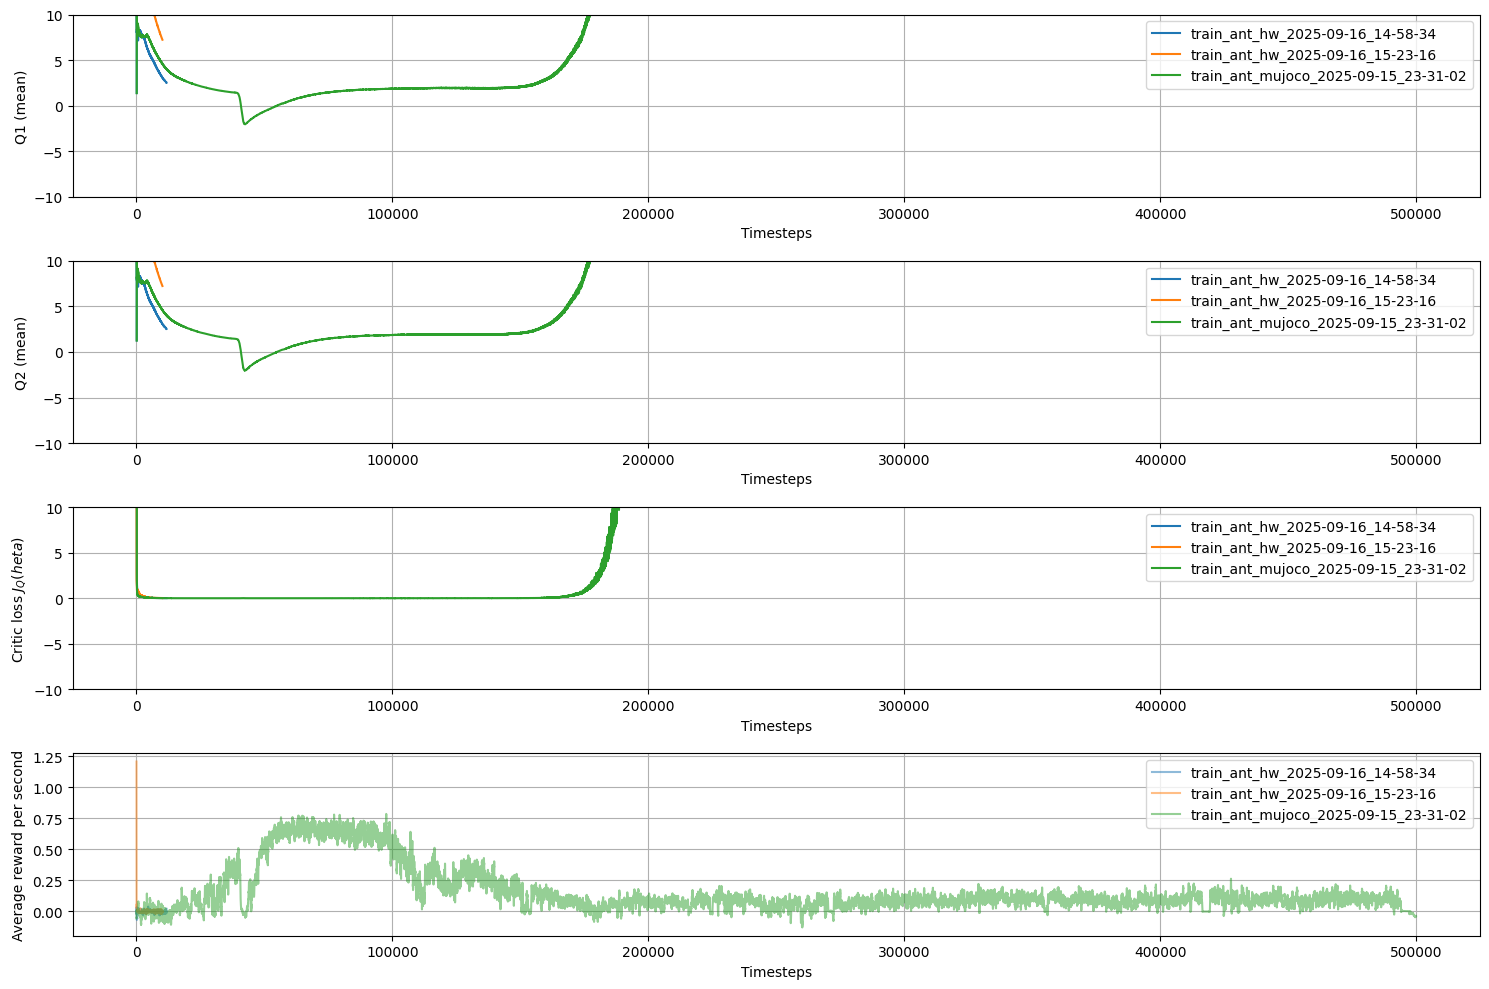

In [4]:
fig, ax = plt.subplots(4, 1, figsize=(15, 10))
for q1, label in zip(q1_values, labels):
    q1_np = np.array(q1)
    ax[0].plot(q1_np[:,0], q1_np[:,1], label=label)
ax[0].set_xlabel("Timesteps")
ax[0].set_ylabel("Q1 (mean)")
ax[0].grid(True)
ax[0].set_ylim(-10, 10)
ax[0].legend()

for q2, label in zip(q2_values, labels):
    q2_np = np.array(q2)
    ax[1].plot(q2_np[:,0], q2_np[:,1], label=label)
ax[1].set_xlabel("Timesteps")
ax[1].set_ylabel("Q2 (mean)")
ax[1].grid(True)
ax[1].set_ylim(-10, 10)
ax[1].legend()

for critic_loss, label in zip(critic_losses, labels):
    critic_loss_np = np.array(critic_loss)
    ax[2].plot(critic_loss_np[:,0], critic_loss_np[:,1], label=label)
ax[2].set_xlabel("Timesteps")
ax[2].set_ylabel("Critic loss $J_Q(\theta)$")
ax[2].grid(True)
ax[2].set_ylim(-10, 10)
ax[2].legend()

for average_reward, label in zip(average_rewards, labels):
    average_reward_np = np.array(average_reward)
    ax[3].plot(average_reward_np[:,0], average_reward_np[:,1], alpha=0.5, label=label)
ax[3].set_xlabel("Timesteps")
ax[3].set_ylabel("Average reward per second")
ax[3].grid(True)
ax[3].legend()
plt.tight_layout()

## Target



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


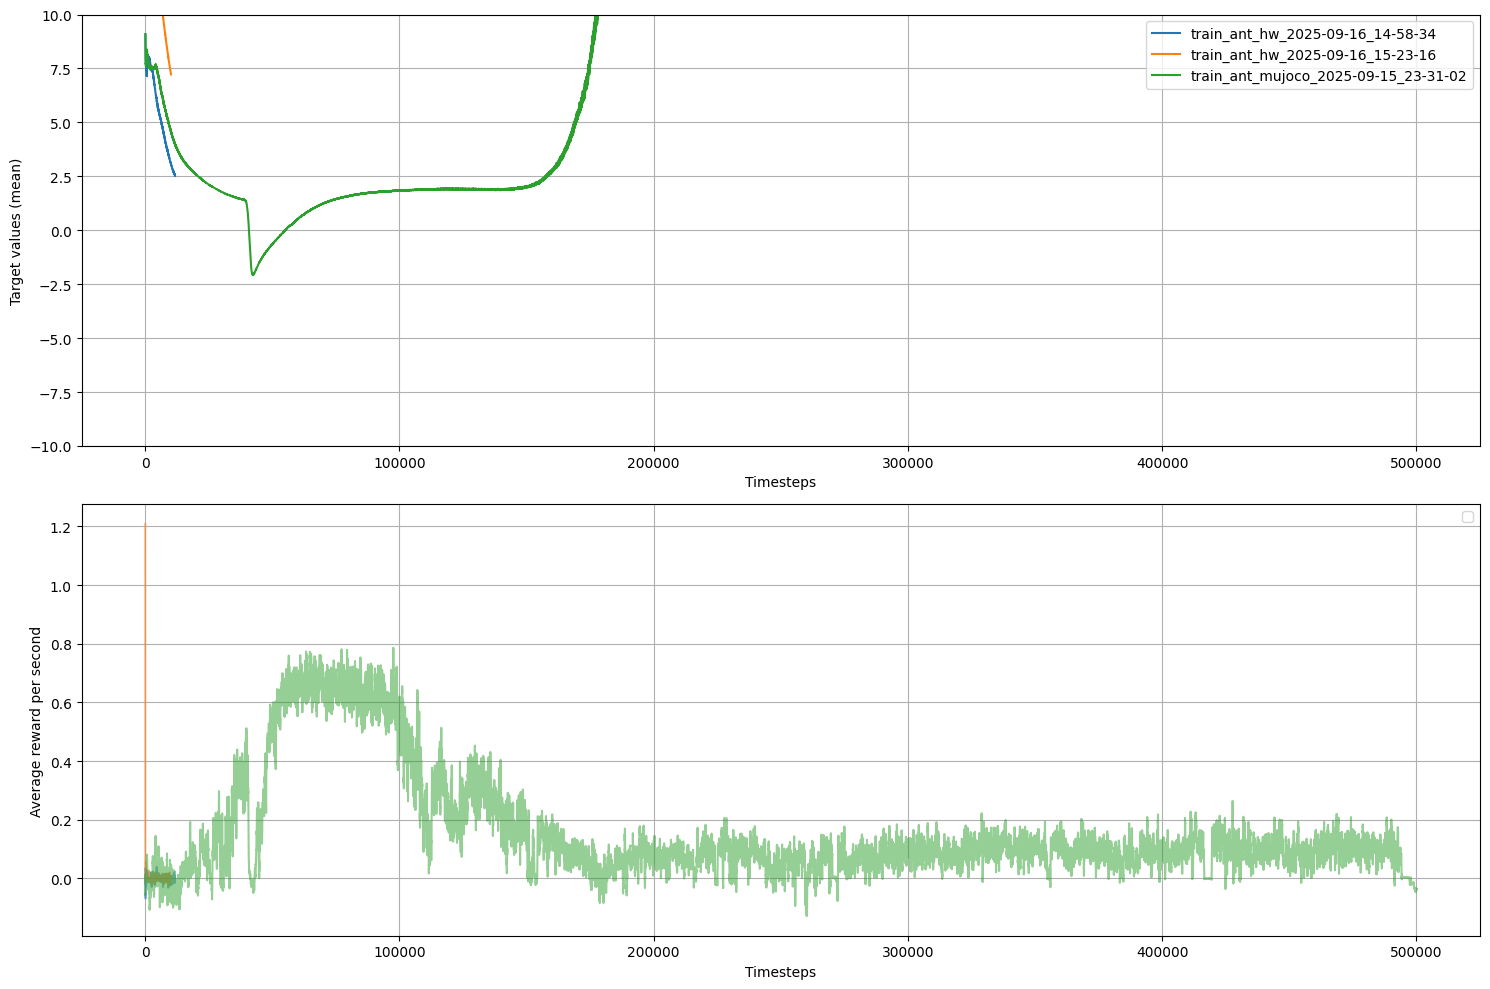

In [5]:

fig, ax = plt.subplots(2, 1, figsize=(15, 10))
for target_values_mean, label in zip(target_values_mean, labels):
    target_values_mean_np = np.array(target_values_mean)
    ax[0].plot(target_values_mean_np[:,0], target_values_mean_np[:,1], label=label)
ax[0].set_xlabel("Timesteps")
ax[0].set_ylabel("Target values (mean)")
ax[0].grid(True)
ax[0].set_ylim(-10, 10)
ax[0].legend()

for average_reward, label in zip(average_rewards, labels):
    average_reward_np = np.array(average_reward)
    ax[1].plot(average_reward_np[:,0], average_reward_np[:,1], alpha=0.5)
ax[1].set_xlabel("Timesteps")
ax[1].set_ylabel("Average reward per second")
ax[1].grid(True)
ax[1].legend()
plt.tight_layout()